## Setup

In [57]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

REPORTS_DIR = Path.cwd() / "reports"

In [58]:
palette = [
    "#0072B2",
    "#6EC6F0",
    "#1A3A6B",
    "#77D4CC",
    "#009E73",
    "#44AA99",
    "#F2E55C",
    "#E69F00",
    "#556B00",
    "#D4669A",
    "#CC3311",
    "#DDDDDD",
    "#222222",
    "#882255"
]

cmap = mcolors.ListedColormap(palette, name="custom")

## Load Reports

In [59]:
def load_reports(report_dir):
    reports = {}
    for p in report_dir.glob("*_build_status.json"):
        repo = p.stem.replace("_build_status", "")
        with p.open() as f: raw = json.load(f)
        reports[repo] = raw["report"]
    return reports

reports = load_reports(REPORTS_DIR)
print("repos:", len(reports))

repos: 9


## Convert to DataFrames

In [60]:
def flatten_totals(reports):
    rows = []
    for repo, row in reports.items():
        report = row if "totals" in row else row["report"]
        section_labels = report["labels"]["sections"]
        field_labels = report["labels"]["fields"]
        for section, metrics in report["totals"].items():
            section_label = section_labels[section]
            for metric, value in metrics.items():
                metric_label = field_labels[metric]
                rows.append({
                    "repo": repo,
                    "section": section_label,
                    "metric": metric_label,
                    "value": value
                })
        section_timing = "Timing"
        report = row if "timing" in row else row["report"]
        phase_labels = report["labels"]["phases"]
        rows.append({
            "repo": repo,
            "section": section_timing,
            "metric": field_labels["build_total_seconds"],
            "value": report["timing"]["build_total_seconds"]
        })
        rows.append({
            "repo": repo,
            "section": section_timing,
            "metric": field_labels["build_wall_seconds"],
            "value": report["timing"]["build_wall_seconds"]
        })
        for phase, time in report["timing"]["build_phase_timings"].items():
            rows.append({
                "repo": repo,
                "section": section_timing,
                "metric": phase_labels[phase],
                "value": time
            })

    return pd.DataFrame(rows)

totals_df= flatten_totals(reports)

In [61]:
def flatten_scopes(reports):
    rows = []
    for repo, row in reports.items():
        report = row if "scopes" in row else row["report"]
        section_labels = report["labels"]["sections"]
        field_labels = report["labels"]["fields"]
        scope_labels = report["labels"]["scopes"]
        for scope, sections in report["scopes"].items():
            scope_label = scope_labels[scope]
            for section, metrics in sections.items():
                section_label = section_labels[section]
                for metric, value in metrics.items():
                    metric_label = field_labels[metric]
                    rows.append({
                        "repo": repo,
                        "scope": scope_label,
                        "section": section_label,
                        "metric": metric_label,
                        "value": value
                    })

    return pd.DataFrame(rows)

scopes_df= flatten_scopes(reports)

In [62]:
def flatten_languages(reports):
    rows = []
    for repo, row in reports.items():
        report = row if "languages" in row else row["report"]
        section_labels = report["labels"]["sections"]
        field_labels = report["labels"]["fields"]
        for language, sections in report["languages"].items():
            language_label = language
            for section, metrics in sections.items():
                section_label = section_labels[section]
                for metric, value in metrics.items():
                    metric_label = field_labels[metric]
                    rows.append({
                        "repo": repo,
                        "language": language_label,
                        "section": section_label,
                        "metric": metric_label,
                        "value": value
                    })

    return pd.DataFrame(rows)

languages_df= flatten_languages(reports)

## Service functions

In [63]:
def df_section(df, section):
    subset = df[df.section == section]
    return subset.pivot(index="repo", columns="metric", values="value")

## Overview

In [64]:
totals_pivot = totals_df.pivot(
    index="repo",
    columns=["section","metric"],
    values="value")

totals_pivot

section      Call Materialization          Callsites                         \
metric       Finalized Call Edges Accepted Callsites Not Accepted Callsites   
repo                                                                          
airbyte                   14157.0            14997.0                  650.0   
commons-lang               5376.0             5376.0                  316.0   
eslint                      833.0              834.0                   48.0   
guava                     34833.0            34844.0                 1795.0   
nodebb                     3430.0             3499.0                 2405.0   
npm-cli                    5577.0             5582.0                  296.0   
pydantic                   2708.0             2717.0                  546.0   
rollup                     8101.0             8143.0                 3729.0   
sympy                     59662.0            60213.0                12450.0   

section                                         Not Accepted Callsites  \
metric       Observed Syntactic Callsites Insufficient Static Evidence   
repo                                                                     
airbyte                           15647.0                        358.0   
commons-lang                       5692.0                        127.0   
eslint                              882.0                         41.0   
guava                             36639.0                        507.0   
nodebb                             5904.0                       1228.0   
npm-cli                            5878.0                        271.0   
pydantic                           3263.0                        539.0   
rollup                            11872.0                       3678.0   
sympy                             72663.0                      12430.0   

section                                                                \
metric       Outside Static Contract Structural Mismatch Unclassified   
repo                                                                    
airbyte                        201.0                91.0          0.0   
commons-lang                     4.0               185.0          0.0   
eslint                           7.0                 0.0          0.0   
guava                           32.0              1256.0          0.0   
nodebb                        1177.0                 0.0          0.0   
npm-cli                         25.0                 0.0          0.0   
pydantic                         7.0                 0.0          0.0   
rollup                          45.0                 6.0          0.0   
sympy                            9.0                11.0          0.0   

section      Structure           ...                    Timing  \
metric           Edges    Files  ... Extract Call Observations   
repo                             ...                             
airbyte        38607.0   3288.0  ...                 17.168381   
commons-lang   16979.0    534.0  ...                  5.903343   
eslint          3251.0   1499.0  ...                  8.082251   
guava         102049.0   3245.0  ...                 29.388653   
nodebb          8680.0    883.0  ...                  5.760913   
npm-cli        15322.0   1545.0  ...                 12.838302   
pydantic       16727.0    407.0  ...                  6.255748   
rollup         20280.0  12474.0  ...                 23.931088   
sympy         112295.0   1590.0  ...                 40.684262   

section                                           \
metric       Diagnostic Classification (Phase I)   
repo                                               
airbyte                                 0.560114   
commons-lang                            0.171425   
eslint                                  0.021381   
guava                                   6.632831   
nodebb                                  0.510698   
npm-cli                                 0.181339   
pydantic                

In [65]:
timing_total_df = df_section(totals_df, "Timing").copy()
timing_total_df["Build Wall Time"] = (
    timing_total_df["Build Wall Time"]
    - timing_total_df["Diagnostic Classification (Phase I)"]
    - timing_total_df["Diagnostic Classification (Phase II)"])

timing_total_df = timing_total_df.sort_values("Build Wall Time", ascending=True)

In [66]:
timing_total_df = df_section(totals_df, "Timing")[["Build Wall Time"]]
timing_total_df = timing_total_df.sort_values("Build Wall Time", ascending=True)
timing_total_df = timing_total_df.join(df_section(totals_df, "Structure")[["Nodes", "Edges"]])
timing_total_df["Nodes + Edges"] = timing_total_df["Nodes"] + timing_total_df["Edges"]
timing_total_df["Time per 1K Nodes"] = timing_total_df["Build Wall Time"] / (timing_total_df["Nodes"] / 1000)
timing_total_df["Time per 1K Edges"] = timing_total_df["Build Wall Time"] / (timing_total_df["Edges"] / 1000)
timing_total_df["Time per 1K (Nodes + Edges)"] = timing_total_df["Build Wall Time"] / (timing_total_df["Nodes + Edges"] / 1000)

timing_mean = timing_total_df.mean(numeric_only=True)
timing_median = timing_total_df.median(numeric_only=True)
timing_std = timing_total_df.std(numeric_only=True)

timing_mean.name = "Mean"
timing_median.name = "Median"
timing_std.name = "Std"

timing_overview_df = pd.concat([timing_total_df, timing_mean.to_frame().T, timing_std.to_frame().T, timing_median.to_frame().T]).round(2)
timing_overview_df

metric,Build Wall Time,Nodes,Edges,Nodes + Edges,Time per 1K Nodes,Time per 1K Edges,Time per 1K (Nodes + Edges)
nodebb,17.42,3349.00,8680.00,12029.00,5.20,2.01,1.45
commons-lang,20.81,11566.00,16979.00,28545.00,1.80,1.23,0.73
eslint,20.93,3115.00,3251.00,6366.00,6.72,6.44,3.29
pydantic,22.58,13301.00,16727.00,30028.00,1.70,1.35,0.75
npm-cli,35.69,9752.00,15322.00,25074.00,3.66,2.33,1.42
airbyte,63.25,25275.00,38607.00,63882.00,2.50,1.64,0.99
rollup,95.78,19675.00,20280.00,39955.00,4.87,4.72,2.40
guava,144.72,64135.00,102049.00,166184.00,2.26,1.42,0.87
sympy,241.68,40980.00,112295.00,153275.00,5.90,2.15,1.58
Mean,73.65,21238.67,37132.22,58370.89,3.84,2.59,1.50


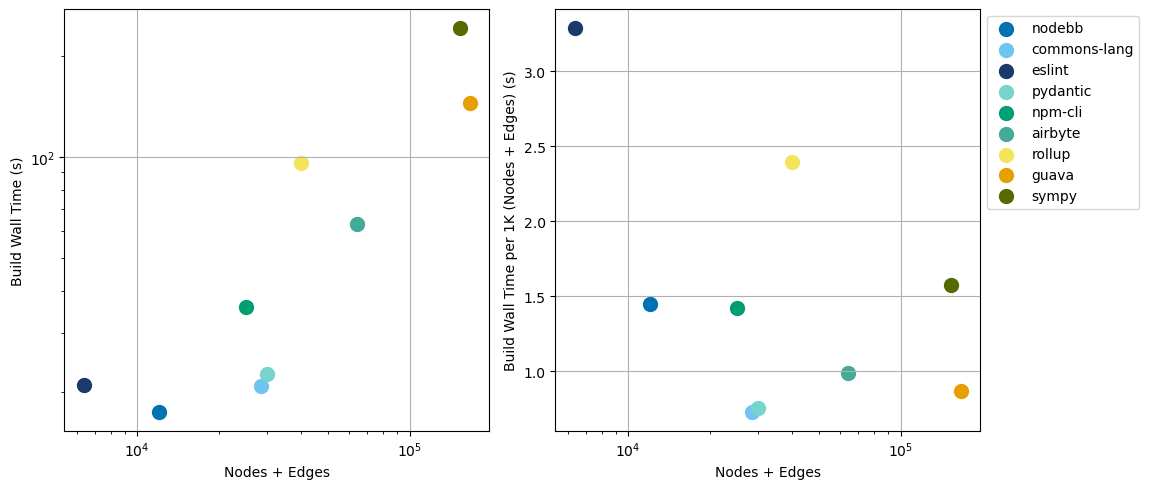

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True)

for i, repo in enumerate(timing_total_df.index):
    color = palette[i % len(palette)]
    x = timing_total_df.loc[repo, "Nodes + Edges"]
    y1 = timing_total_df.loc[repo, "Build Wall Time"]
    y2 = timing_total_df.loc[repo, "Time per 1K (Nodes + Edges)"]

    axes[0].scatter(x, y1, color=color, s=100, label=repo)
    axes[1].scatter(x, y2, color=color, s=100)

axes[0].set_xlabel("Nodes + Edges")
axes[0].set_ylabel("Build Wall Time (s)")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].grid(True)

axes[1].set_xlabel("Nodes + Edges")
axes[1].set_ylabel("Build Wall Time per 1K (Nodes + Edges) (s)")
axes[1].set_xscale("log")
axes[1].grid(True)

fig.legend(loc="upper left", bbox_to_anchor=(0.985, 0.97))
plt.tight_layout()
plt.show()

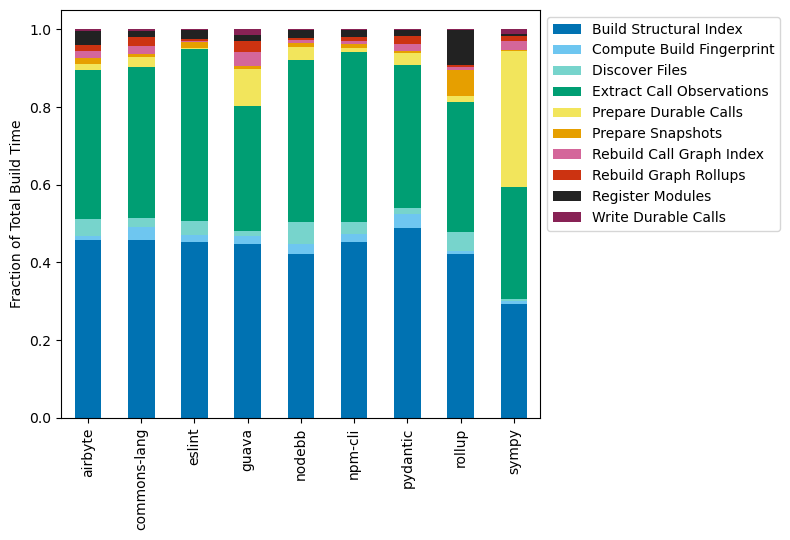

In [68]:
timing_phases_df = df_section(totals_df, "Timing").drop(columns=["Build Total Time", "Build Wall Time", "Diagnostic Classification (Phase I)", "Diagnostic Classification (Phase II)"], errors="ignore")
timing_phases_df = timing_phases_df.div(timing_phases_df.sum(axis=1), axis=0)

timing_phases_df.plot( kind="bar", stacked=True, colormap=cmap, figsize=(8, 5.5))
plt.legend(bbox_to_anchor=(1, 1), loc="upper left")
plt.xlabel("")
plt.ylabel("Fraction of Total Build Time")
plt.tight_layout()
plt.show()

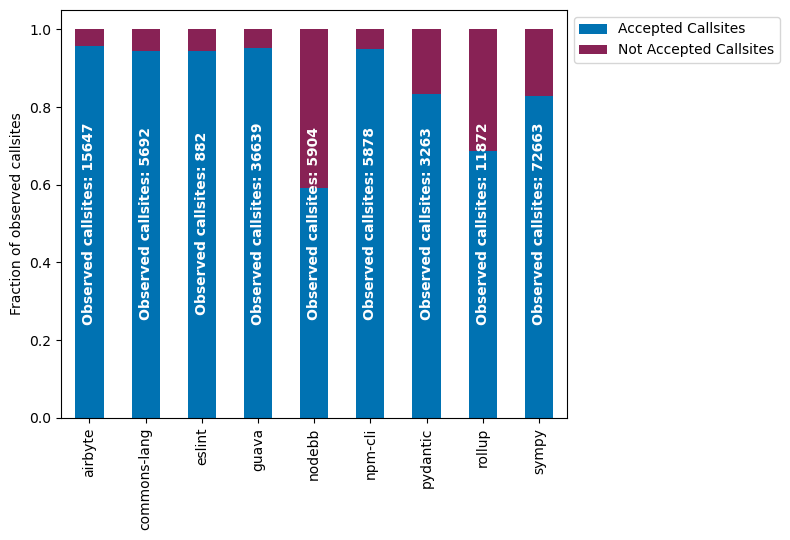

In [69]:
observed_callsites = df_section(totals_df, "Callsites")["Observed Syntactic Callsites"]

callsites_df = df_section(totals_df, "Callsites").drop(columns=["Observed Syntactic Callsites"])
callsites_df = callsites_df.div(callsites_df.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(8,5.5))

callsites_df.plot( kind="bar", stacked=True, colormap=cmap, ax=ax)

for i, (repo, value) in enumerate(observed_callsites.items()):
    ax.text(i, 0.5, f"Observed callsites: {int(value)}", rotation=90, ha="center", va="center", fontsize=10, fontweight="bold", color="white")

plt.legend(bbox_to_anchor=(1, 1), loc="upper left")
plt.xlabel("")
plt.ylabel("Fraction of observed callsites")
plt.tight_layout()
plt.show()

In [70]:
callsites_df

metric,Accepted Callsites,Not Accepted Callsites
repo,,
airbyte,0.958458,0.041542
commons-lang,0.944483,0.055517
eslint,0.945578,0.054422
guava,0.951008,0.048992
nodebb,0.592649,0.407351
npm-cli,0.949643,0.050357
pydantic,0.832669,0.167331
rollup,0.685900,0.314100
sympy,0.828661,0.171339


## Language breakdown

In [71]:
languages_pivot = languages_df.pivot(
    index=["repo","language"],
    columns=["section","metric"],
    values="value")
languages_pivot

section                 Call Materialization          Callsites  \
metric                  Finalized Call Edges Accepted Callsites   
repo         language                                             
airbyte      java                       1556               1556   
             javascript                   74                 74   
             python                    12525              13365   
             typescript                    2                  2   
commons-lang java                       5376               5376   
eslint       javascript                  833                834   
             typescript                    0                  0   
guava        java                      34833              34844   
             javascript                    0                  0   
nodebb       javascript                 3430               3499   
             typescript                    0                  0   
npm-cli      javascript                 4207               4212   
             python                     1370               1370   
pydantic     javascript                    8                  8   
             python                     2700               2709   
rollup       javascript                 6004               6004   
             typescript                 2097               2139   
sympy        python                    59662              60213   

section                                                                      \
metric                  Not Accepted Callsites Observed Syntactic Callsites   
repo         language                                                         
airbyte      java                           67                         1623   
             javascript                      0                           74   
             python                        583                        13948   
             typescript                      0                            2   
commons-lang java                          316                         5692   
eslint       javascript                     48                          882   
             typescript                      0                            0   
guava        java                         1795                        36639   
             javascript                      0                            0   
nodebb       javascript                   2405                         5904   
             typescript                      0                            0   
npm-cli      javascript                    271                         4483   
             python                         25                         1395   
pydantic     javascript                      0                            8   
             python                        546                         3255   
rollup       javascript                   3509                         9513   
             typescript                    220                         2359   
sympy        python                      12450                        72663   

section                 Structure                
metric                      Edges  Files  Nodes  
repo         language                            
airbyte      java            5385    473   4144  
             javascript       201     44    147  
             python         33013   2768  20976  
             typescript         8      3      8  
commons-lang java           16979    534  11566  
eslint       javascript      3167   1474   3017  
             typescript        84     25     98  
guava        java          102045   3243  64129  
             javascript         4      2      6  
nodebb       javascript      8550    877   3220  
             typescript       130      6    129  
npm-cli      javascript     12498   1487   8306  
             python          2824     58   1446  
pydantic     javascript        18      6     16  
             python         16709    401  13285  
rollup       javascript     1409

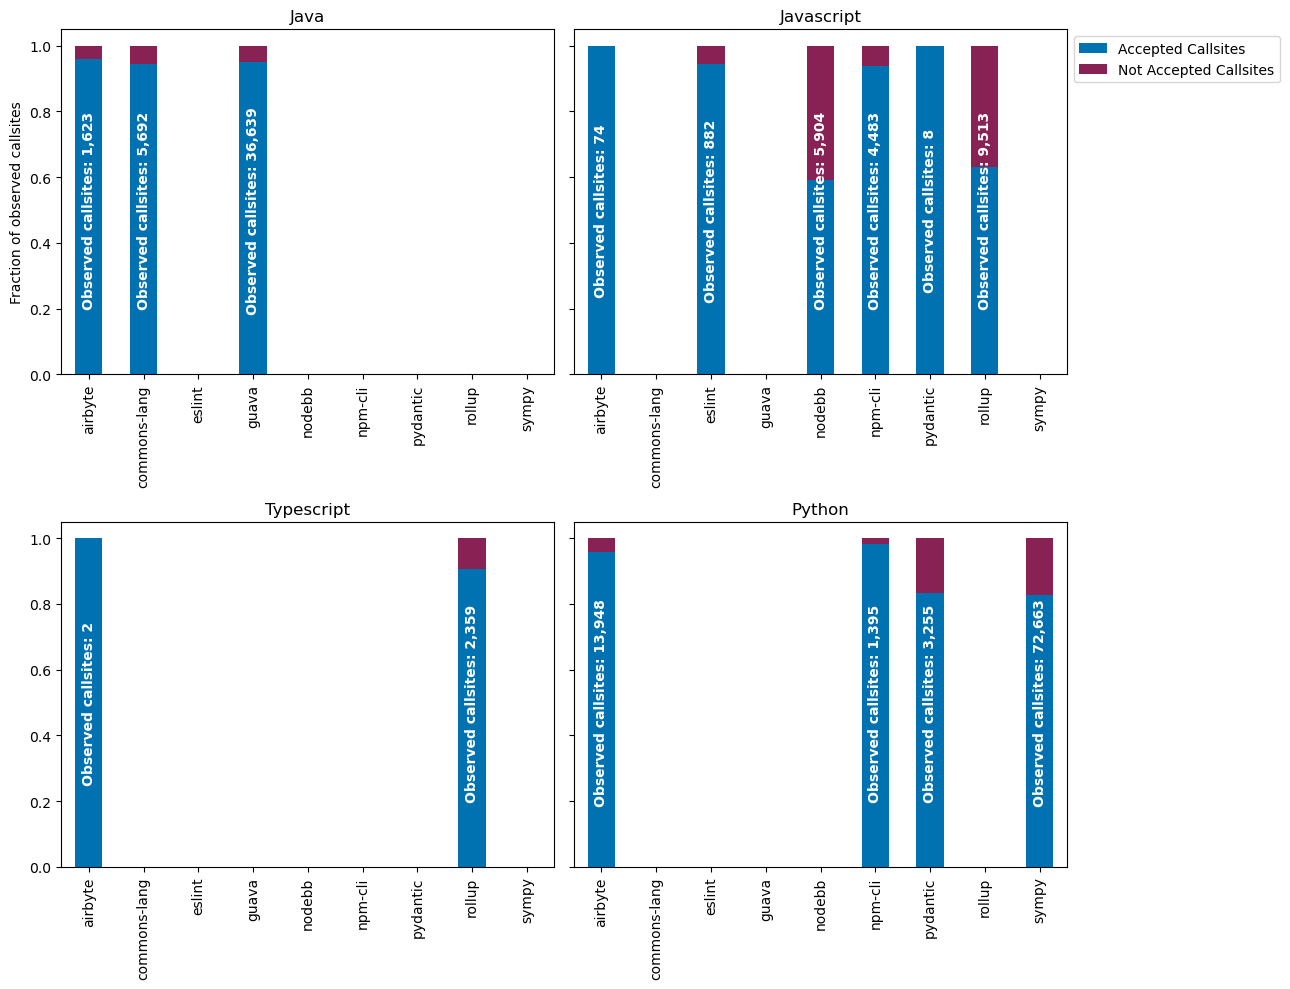

In [72]:
observed_callsites = languages_pivot.xs("Callsites", axis=1, level="section")["Observed Syntactic Callsites"]

callsites_df = languages_pivot.xs("Callsites", axis=1, level="section").drop(columns=["Observed Syntactic Callsites"])
callsites_df = callsites_df.div(callsites_df.sum(axis=1), axis=0)
callsites_df = callsites_df.sort_index(level="repo")

all_repos = callsites_df.index.get_level_values("repo").unique()

java_df = callsites_df.xs("java", level="language").reindex(all_repos, fill_value=0)
javascript_df = callsites_df.xs("javascript", level="language").reindex(all_repos, fill_value=0)
typescript_df = callsites_df.xs("typescript", level="language").reindex(all_repos, fill_value=0)
python_df = callsites_df.xs("python", level="language").reindex(all_repos, fill_value=0)

java_callsites = observed_callsites.xs("java", level="language").reindex(all_repos, fill_value=0)
javascript_callsites = observed_callsites.xs("javascript", level="language").reindex(all_repos, fill_value=0)
typescript_callsites = observed_callsites.xs("typescript", level="language").reindex(all_repos, fill_value=0)
python_callsites = observed_callsites.xs("python", level="language").reindex(all_repos, fill_value=0)

fig, axes = plt.subplots(2,2, figsize=(13,10), sharey=True)

java_df.plot(kind="bar", stacked=True, colormap=cmap, ax=axes[0,0], legend=False)
javascript_df.plot(kind="bar", stacked=True, colormap=cmap, ax=axes[0,1])
typescript_df.plot(kind="bar", stacked=True, colormap=cmap, ax=axes[1,0], legend=False)
python_df.plot(kind="bar", stacked=True, colormap=cmap, ax=axes[1,1], legend=False)

for i, (repo, value) in enumerate(java_callsites.items()):
    axes[0,0].text(i, 0.5, f"Observed callsites: {int(value):,}", rotation=90, ha="center", va="center", fontsize=10, fontweight="bold", color="white")

for i, (repo, value) in enumerate(javascript_callsites.items()):
    axes[0,1].text(i, 0.5, f"Observed callsites: {int(value):,}", rotation=90, ha="center", va="center", fontsize=10, fontweight="bold", color="white")

for i, (repo, value) in enumerate(typescript_callsites.items()):
    axes[1,0].text(i, 0.5, f"Observed callsites: {int(value):,}", rotation=90, ha="center", va="center", fontsize=10, fontweight="bold", color="white")

for i, (repo, value) in enumerate(python_callsites.items()):
    axes[1,1].text(i, 0.5, f"Observed callsites: {int(value):,}", rotation=90, ha="center", va="center", fontsize=10, fontweight="bold", color="white")

axes[0,0].set_title("Java")
axes[0,1].set_title("Javascript")
axes[1,0].set_title("Typescript")
axes[1,1].set_title("Python")

for ax in axes.flat: ax.set_xlabel("")
axes[0,0].set_ylabel("Fraction of observed callsites")
axes[0,1].legend(bbox_to_anchor=(1,1), loc="upper left")

plt.tight_layout()
plt.show()

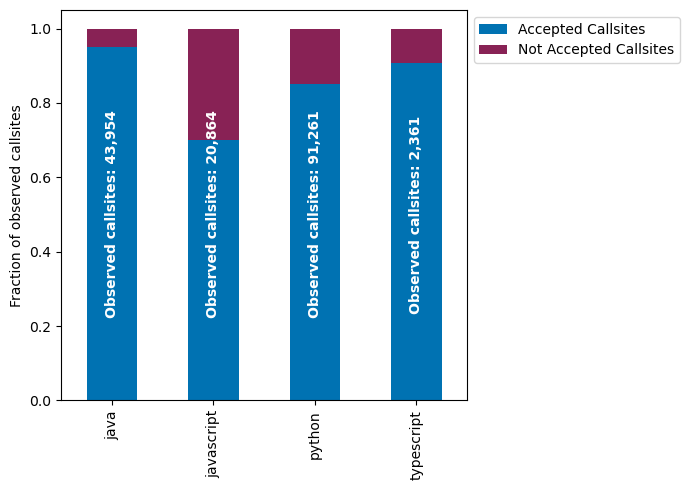

In [73]:
callsites_raw_df = languages_pivot.groupby(level="language").sum()
callsites_counts = callsites_raw_df.xs("Callsites", axis=1, level="section")["Observed Syntactic Callsites"]

callsites_df = languages_pivot.groupby(level="language").sum()
callsites_df = callsites_df.xs("Callsites", axis=1, level="section").drop(columns=["Observed Syntactic Callsites"])
callsites_df = callsites_df.div(callsites_df.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(7, 5))

callsites_df.plot( kind="bar", stacked=True, colormap=cmap, ax=ax)

for i, (lang, value) in enumerate(callsites_counts.items()):
    ax.text(i, 0.5, f"Observed callsites: {int(value):,}", rotation=90, ha="center", va="center", fontsize=10, fontweight="bold", color="white")

ax.legend(bbox_to_anchor=(1,1), loc="upper left")
ax.set_xlabel("")
ax.set_ylabel("Fraction of observed callsites")

plt.tight_layout()
plt.show()

In [74]:
callsites_raw_df

section    Call Materialization          Callsites                         \
metric     Finalized Call Edges Accepted Callsites Not Accepted Callsites   
language                                                                    
java                      41765              41776                   2178   
javascript                14556              14631                   6233   
python                    76257              77657                  13604   
typescript                 2099               2141                    220   

section                                 Structure                
metric     Observed Syntactic Callsites     Edges  Files  Nodes  
language                                                         
java                              43954    124409   4250  79839  
javascript                        20864     38536  16008  31973  
python                            91261    164841   4817  76687  
typescript                         2361      6404    390   2649

In [75]:
callsites_df

metric,Accepted Callsites,Not Accepted Callsites
language,,
java,0.950448,0.049552
javascript,0.701256,0.298744
python,0.850933,0.149067
typescript,0.906819,0.093181


## Scope breakdown

In [76]:
scopes_pivot = scopes_df.pivot(
    index=["repo","scope"],
    columns=["section","metric"],
    values="value")
scopes_pivot

section                Call Materialization          Callsites  \
metric                 Finalized Call Edges Accepted Callsites   
repo         scope                                               
airbyte      Non-Tests                13552              14392   
             Tests                      605                605   
commons-lang Non-Tests                 3325               3325   
             Tests                     2051               2051   
eslint       Non-Tests                  815                816   
             Tests                       18                 18   
guava        Non-Tests                22928              22939   
             Tests                    11905              11905   
nodebb       Non-Tests                 3406               3473   
             Tests                       24                 26   
npm-cli      Non-Tests                 5380               5385   
             Tests                      197                197   
pydantic     Non-Tests                 1594               1594   
             Tests                     1114               1123   
rollup       Non-Tests                 2135               2177   
             Tests                     5966               5966   
sympy        Non-Tests                24770              24827   
             Tests                    34892              35386   

section                                                                     \
metric                 Not Accepted Callsites Observed Syntactic Callsites   
repo         scope                                                           
airbyte      Non-Tests                    641                        15033   
             Tests                          9                          614   
commons-lang Non-Tests                     78                         3403   
             Tests                        238                         2289   
eslint       Non-Tests                     44                          860   
             Tests                          4                           22   
guava        Non-Tests                    617                        23556   
             Tests                       1178                        13083   
nodebb       Non-Tests                   2402                         5875   
             Tests                          3                           29   
npm-cli      Non-Tests                    296                         5681   
             Tests                          0                          197   
pydantic     Non-Tests                    243                         1837   
             Tests                        303                         1426   
rollup       Non-Tests                    227                         2404   
             Tests                       3502                         9468   
sympy        Non-Tests                   3124                        27951   
             Tests                       9326                        44712   

section                Structure                
metric                     Edges  Files  Nodes  
repo         scope                              
airbyte      Non-Tests     36483   3098  23583  
             Tests          2124    190   1692  
commons-lang Non-Tests      8306    259   4973  
             Tests          8673    275   6593  
eslint       Non-Tests      2525    477   1818  
             Tests           726   1022   1297  
guava        Non-Tests     63280   2001  36688  
             Tests         38769   1244  27447  
nodebb       Non-Tests      8155    809   3244  
             Tests           525     74    105  
npm-cli      Non-Tests     14283   1096   8797  
             Tests          1039    449    955  
pydantic     Non-Tests      4493    123   2458  
             Tests         12234    284  10843  
rollup       Non-Tests      6329    390   2510  
             Tests         13951  12084  17165  
sympy        Non-Tests     57130    907  26

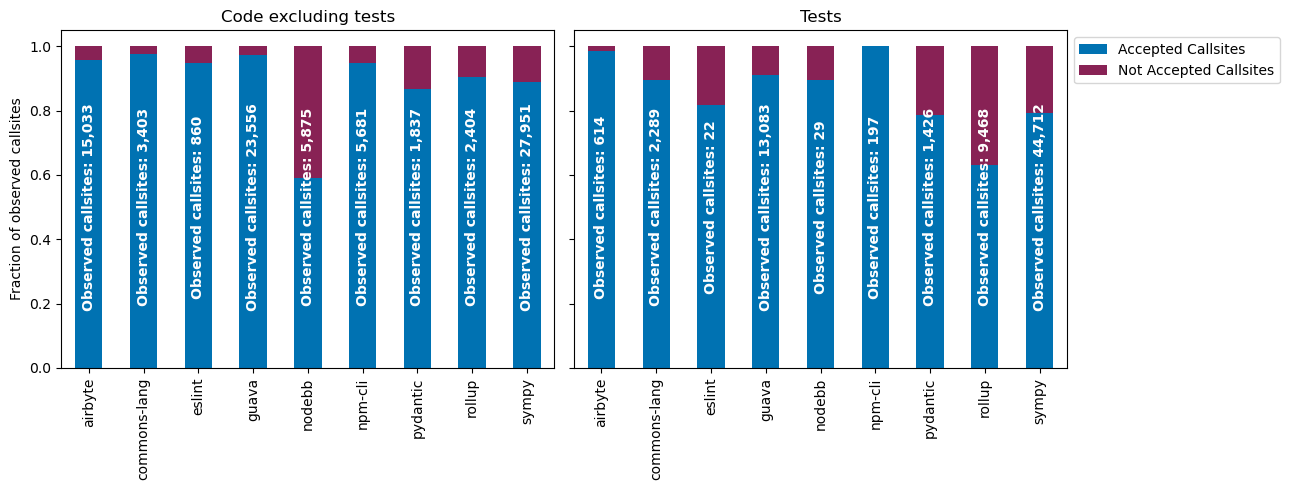

In [77]:
callsites_counts = scopes_pivot.xs("Callsites", axis=1, level="section")["Observed Syntactic Callsites"]
counts_non_tests = callsites_counts.xs("Non-Tests", level="scope")
counts_tests = callsites_counts.xs("Tests", level="scope")

callsites_df = scopes_pivot.xs("Callsites", axis=1, level="section").drop(columns=["Observed Syntactic Callsites"])
callsites_df = callsites_df.div(callsites_df.sum(axis=1), axis=0)
callsites_df = callsites_df.sort_index(level="repo")

non_test_df = callsites_df.xs("Non-Tests", level="scope")
tests_df = callsites_df.xs("Tests", level="scope")

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

non_test_df.plot(kind="bar", stacked=True, colormap=cmap, ax=axes[0],legend=False)
tests_df.plot(kind="bar", stacked=True, colormap=cmap, ax=axes[1])

for i, (repo, value) in enumerate(counts_non_tests.items()):
    axes[0].text(i, 0.5, f"Observed callsites: {int(value):,}", rotation=90, ha="center", va="center", fontsize=10, fontweight="bold", color="white")

for i, (repo, value) in enumerate(counts_tests.items()):
    axes[1].text(i, 0.5, f"Observed callsites: {int(value):,}", rotation=90, ha="center", va="center", fontsize=10, fontweight="bold", color="white")
    
axes[0].set_title("Code excluding tests")
axes[1].set_title("Tests")
axes[0].set_xlabel("")
axes[0].set_ylabel("Fraction of observed callsites")
axes[1].set_ylabel("")
axes[1].set_xlabel("")
axes[1].legend(bbox_to_anchor=(1,1),loc="upper left")
plt.tight_layout()
plt.show()

## Diagnostics

In [78]:
df_section(totals_df, "Not Accepted Callsites")

metric,Insufficient Static Evidence,Outside Static Contract,Structural Mismatch,Unclassified
repo,,,,
airbyte,358.0,201.0,91.0,0.0
commons-lang,127.0,4.0,185.0,0.0
eslint,41.0,7.0,0.0,0.0
guava,507.0,32.0,1256.0,0.0
nodebb,1228.0,1177.0,0.0,0.0
npm-cli,271.0,25.0,0.0,0.0
pydantic,539.0,7.0,0.0,0.0
rollup,3678.0,45.0,6.0,0.0
sympy,12430.0,9.0,11.0,0.0


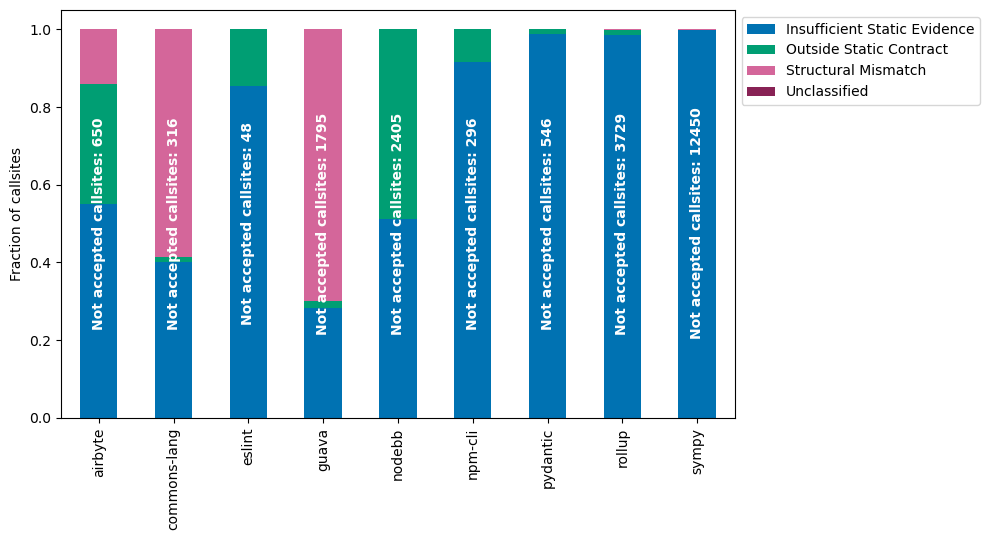

In [79]:
pre_persist = df_section(totals_df, "Callsites")["Not Accepted Callsites"]

pre_persist_df = df_section(totals_df, "Not Accepted Callsites")
pre_persist_df = pre_persist_df.div(pre_persist_df.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(10,5.5))

pre_persist_df.plot( kind="bar", stacked=True, colormap=cmap, ax=ax)

for i, (repo, value) in enumerate(pre_persist.items()):
    ax.text(i, 0.5, f"Not accepted callsites: {int(value)}", rotation=90, ha="center", va="center", fontsize=10, fontweight="bold", color="white")

plt.legend(bbox_to_anchor=(1, 1), loc="upper left")
plt.xlabel("")
plt.ylabel("Fraction of callsites")
plt.tight_layout()
plt.show()